In [91]:
#!pip install langchain==0.3.20

In [92]:
#!pip install langchain-openai==0.3.9

In [93]:
#!pip install langchain-community==0.3.20

In [94]:
#!pip install langgraph==0.3.18

In [4]:
# Install ChromaDB Langchain Wrapper for vector DB

In [95]:
#!pip install langchain-chroma==0.2.2

In [1]:
# Intall jupyter widgets for building form UI elements

In [96]:
#!pip install ipywidgets

In [97]:
#!pip install jupyter-ui-poll==1.0.0

In [5]:
from getpass import getpass
OPENAI_API_KEY=getpass("Enter OPENAI API key")

Enter OPENAI API key··········


In [6]:
import os
os.environ["OPENAI_API_KEY"]=OPENAI_API_KEY

In [7]:
# llm=ChatOpenAI(model="gpt-4o-mini")

In [8]:
# Loading data set

In [9]:
!gdown 1_bQj7VkXDMwwqJmspFgRzH2mgK1CVMUY

Downloading...
From: https://drive.google.com/uc?id=1_bQj7VkXDMwwqJmspFgRzH2mgK1CVMUY
To: /content/healthcare_db.json
100% 10.6k/10.6k [00:00<00:00, 30.5MB/s]


In [10]:
import json

In [11]:
with open("/content/healthcare_db.json","r")as f:
  knowledge_data_base=json.load(f)

In [12]:
knowledge_data_base[:3]

[{'text': "Question: How can I view my healthcare billing statement online? Answer: You can view your billing statement by logging into your patient portal and selecting 'Billing Statements'.",
  'metadata': {'category': 'billing'}},
 {'text': 'Question: What payment methods are accepted for medical bills? Answer: We accept credit cards, bank transfers, and insurance payments for settling your medical bills.',
  'metadata': {'category': 'billing'}},
 {'text': 'Question: Can I get a detailed invoice for my medical services? Answer: Yes, a detailed invoice is available in your patient portal under the billing section.',
  'metadata': {'category': 'billing'}}]

In [14]:
from langchain.docstore.document import Document
from tqdm import tqdm

In [16]:
processed_doc_data=[]

In [18]:
for doc in tqdm(knowledge_data_base):
  metadata=doc['metadata']
  data=doc['text']
  processed_doc_data.append(Document(metadata=metadata,page_content=data))

100%|██████████| 40/40 [00:00<00:00, 92589.49it/s]


In [19]:
processed_doc_data[:3]

[Document(metadata={'category': 'billing'}, page_content="Question: How can I view my healthcare billing statement online? Answer: You can view your billing statement by logging into your patient portal and selecting 'Billing Statements'."),
 Document(metadata={'category': 'billing'}, page_content='Question: What payment methods are accepted for medical bills? Answer: We accept credit cards, bank transfers, and insurance payments for settling your medical bills.'),
 Document(metadata={'category': 'billing'}, page_content='Question: Can I get a detailed invoice for my medical services? Answer: Yes, a detailed invoice is available in your patient portal under the billing section.')]

In [21]:
# Create vector database

In [22]:
from langchain_openai import OpenAIEmbeddings

In [23]:
open_ai_embed_models=OpenAIEmbeddings(model='text-embedding-3-small')

In [24]:
from langchain_chroma import Chroma

In [27]:
kbase_db=Chroma.from_documents(
    documents=processed_doc_data,
    embedding=open_ai_embed_models,
    collection_metadata={"hnsw:space":"cosine"},
    persist_directory="./knowledge_base"
)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [26]:
# Crate vector database retriever strategy

In [29]:
kbase_search=kbase_db.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={"k":3,"score_threshold":0.3} # score thereshold is minimun 30 % matching
)

In [30]:
query="What payment methods do you accpet?"
metadata_filter={'category':'billing'}

In [31]:
# Update retriever search_kwargs dynamically

In [32]:
kbase_search.search_kwargs['filter']=metadata_filter

In [33]:
#invoking query

In [34]:
kbase_search.invoke(query)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


[Document(id='7d662b09-5b99-4a42-8a2e-3a909fd03097', metadata={'category': 'billing'}, page_content='Question: What payment methods are accepted for medical bills? Answer: We accept credit cards, bank transfers, and insurance payments for settling your medical bills.'),
 Document(id='0b9be736-576a-43ba-8221-4d4d703d8eca', metadata={'category': 'billing'}, page_content='Question: Is there a discount for upfront payment of my medical bill? Answer: Some facilities offer discounts for upfront payments; please contact our billing department for details.'),
 Document(id='3e67a48b-57c3-40dd-8e66-31a07cf03b23', metadata={'category': 'billing'}, page_content='Question: How do I update my billing information on my healthcare account? Answer: You can update your billing details through your online patient portal in the account settings.')]

In [40]:
query="What payment methods do you accpet?"
metadata_filter={'category':'Billing'}
kbase_search.search_kwargs['filter']=metadata_filter
kbase_search.invoke(query)

[]

In [41]:
query="How to book an appointment?"
metadata_filter={'category':'appointments'}
kbase_search.search_kwargs['filter']=metadata_filter
kbase_search.invoke(query)

[Document(id='74b9eecb-92a4-4880-b19d-a4384513cc66', metadata={'category': 'appointments'}, page_content="Question: How do I book a telehealth consultation? Answer: Telehealth appointments can be scheduled by selecting the 'Virtual Visit' option when booking your appointment online."),
 Document(id='388d953e-4906-4099-9252-9c98b17b9016', metadata={'category': 'appointments'}, page_content='Question: Can I request a specific time slot for my appointment? Answer: Yes, you may request a specific time when booking, subject to availability.'),
 Document(id='1d309ba6-fd69-4a2f-b104-366ba1eef5df', metadata={'category': 'appointments'}, page_content='Question: How do I schedule a medical appointment online? Answer: You can schedule an appointment through our patient portal by selecting your preferred date and healthcare provider.')]

In [42]:
# Get an idea of the unique categories of documents we have

In [43]:
# Retrieve all metadata from the collection
results=kbase_db._collection.get( # No filtering , fetches all documents
    include=["metadatas"]  # Include metadata in the result
)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


In [44]:
# Extract unique categories
unique_categories = set()
for metadata in results["metadatas"]:
    if "category" in metadata:
      unique_categories.add(metadata["category"])


In [45]:
print(unique_categories)

{'insurance', 'billing', 'appointments', 'medical_records'}


In [46]:
# Build the router agentic RAG system

In [47]:
# Creating the langgaph

In [48]:
from typing import TypedDict,Literal
from pydantic import BaseModel

In [50]:
class CustomerSupportAgentState(TypedDict):
  customer_query:str
  query_category:str
  query_sentiment:str
  escalation_cust_info:dict
  oncall_cust_info:dict
  final_response:str

In [51]:
class QueryCategory(BaseModel):
    categorized_topic: Literal['Billing', 'Appointments', 'Records', 'Insurance']

class QuerySentiment(BaseModel):
    sentiment: Literal['Positive', 'Neutral', 'Negative', 'Distress']

In [52]:
# Plan the agent workflow structure

In [53]:
from langchain_openai import ChatOpenAI

In [54]:
llm=ChatOpenAI(model="gpt-4o",temperature=0)

In [55]:
# Create function for the langGraph

In [56]:
def categorize_inquiry(support_state: CustomerSupportAgentState) -> CustomerSupportAgentState:
    """
    Classify the customer query into 'Billing', 'Appointments', 'Records' or 'Insurance'.
    """

    query = support_state["customer_query"]
    ROUTE_CATEGORY_PROMPT = """Act as a customer support agent trying to best categorize the customer query.
                               You are a support agent for a healthcare company focusing on providing healthcare services to customers.
                               These services include:
                                - handling billing queries
                                - handling insurance queries
                                - handling appointment booking queries
                                - handling medical records queries

                               Please read the customer query below and
                               determine the best category from the following list:

                               'Billing', 'Appointments', 'Records' or 'Insurance'

                               Remember:
                                - Billing queries will focus more on payment and billing related aspects
                                - Appointments will focus more on booking, rescheduling, cancelling doctor appointments
                                - Records will focus more on updating, sharing, accessing medical records
                                - Insurance will focus more on insurance related queries like claims, updating insurance policy details

                                Return just the category name (from one of the above)

                                Query:
                                {customer_query}
                            """
    prompt = ROUTE_CATEGORY_PROMPT.format(customer_query=query)
    route_category = llm.with_structured_output(QueryCategory).invoke(prompt)

    return {
        "query_category": route_category.categorized_topic
    }

In [57]:
categorize_inquiry({"customer_query": "What doctors are available?"})

{'query_category': 'Appointments'}

In [58]:
categorize_inquiry({"customer_query": "how to update my policy?"})

{'query_category': 'Insurance'}

In [59]:
# Crate a analyze query sentiment function

In [60]:
def analyze_inquiry_sentiment(support_state: CustomerSupportAgentState) -> CustomerSupportAgentState:
    """
    Analyze the sentiment of the customer query as Positive, Neutral, Negative or Distress.
    """

    query = support_state["customer_query"]
    SENTIMENT_CATEGORY_PROMPT = """Act as a customer support agent trying to best categorize the customer query.
                                   You are a support agent for a healthcare company focusing on providing healthcare services to customers.
                                   These services include:
                                    - handling billing queries
                                    - handling insurance queries
                                    - handling appointment booking queries
                                    - handling medical records queries

                                   Please read the customer query below,
                                   analyze its sentiment which should be one from the following list:

                                   'Positive', 'Neutral', 'Negative' or 'Distress'.

                                   Remember these rules when finding the sentiment:
                                     - 'Distress' happens only when the customer is facing a health emergency and might need the on-call emergency doctor
                                     - 'Negative' happens only when the customer is not happy with certain products, services offered by the company

                                   Return just the sentiment (from one of the above)

                                   Query:
                                   {customer_query}
                                """
    prompt = SENTIMENT_CATEGORY_PROMPT.format(customer_query=query)
    sentiment_category = llm.with_structured_output(QuerySentiment).invoke(prompt)

    return {
        "query_sentiment": sentiment_category.sentiment
    }

In [61]:
analyze_inquiry_sentiment({"customer_query": "I am fed up with not able to book appointments in the portal"})

{'query_sentiment': 'Negative'}

In [63]:
# Creating generate department reponse function

In [64]:
from langchain_core.prompts import ChatPromptTemplate
from typing import Dict

def generate_department_response(support_state: CustomerSupportAgentState) -> CustomerSupportAgentState:
    """
    Provide a department support response by combining knowledge from the vector store and LLM.
    """
    # Retrieve category and ensure it is lowercase for metadata filtering
    categorized_topic = support_state["query_category"]
    query = support_state["customer_query"]

    # Use metadata filter for department - specific queries
    if categorized_topic.lower() == "billing":
        metadata_filter = {"category": "billing"}
        department = "Billing"
    elif categorized_topic.lower() == "appointments":
        metadata_filter = {"category": "appointments"}
        department = "Appointments"
    elif categorized_topic.lower() == "records":
        metadata_filter = {"category": "medical_records"}
        department = "Medical Records"
    elif categorized_topic.lower() == "insurance":
        metadata_filter = {"category": "insurance"}
        department = "Insurance"
    # apply metadata filter
    kbase_search.search_kwargs["filter"] = metadata_filter

    # Perform retrieval from VectorDB
    relevant_docs = kbase_search.invoke(query)
    retrieved_content = "\n\n".join(doc.page_content for doc in relevant_docs) # All the three page contents are joined over here


    # Combine retrieved information into the prompt
    prompt = ChatPromptTemplate.from_template(
        """
        Craft a clear and detailed support response for the following customer query about {department}.
        Use the provided knowledge base information to enrich your response.
        In case there is no knowledge base information or you do not know the answer just say:

        Apologies I was not able to answer your question, please reach out to +1-xxx-xxxx

        Customer Query:
        {customer_query}

        Relevant Knowledge Base Information:
        {retrieved_content}
        """
    )

    # Generate the final response using the LLM
    chain = prompt | llm
    reply = chain.invoke({
        "customer_query": query,
        "retrieved_content": retrieved_content,
        "department": department
    }).content

    # Update and return the modified support state
    return {
        "final_response": reply
    }

In [65]:
generate_department_response({"customer_query": "what payment modes do you accept?", "query_category": "Billing"})

{'final_response': 'Thank you for reaching out with your query about payment modes. For settling your medical bills, we accept the following payment methods:\n\n1. Credit Cards\n2. Bank Transfers\n3. Insurance Payments\n\nIf you have any further questions or need assistance with your billing, please feel free to contact our billing department.'}

In [67]:
generate_department_response({"customer_query": "are my doctor records safe?", "query_category": "Records"})

{'final_response': 'Thank you for reaching out with your concern about the safety of your medical records. I want to assure you that we take the security and privacy of your medical information very seriously. Our system complies with HIPAA regulations, which are designed to ensure that your records are securely stored and transmitted. This means that we have implemented strict measures to protect your information from unauthorized access.\n\nAdditionally, when your medical records need to be shared with other healthcare providers, we do so securely and only with authorized providers, in full compliance with HIPAA guidelines. This ensures that your information is handled with the utmost care and confidentiality.\n\nIf you have any further questions or need additional information, please feel free to reach out. Your privacy and the security of your medical records are our top priorities.'}

In [68]:
generate_department_response({"customer_query": "What is addreess", "query_category": "Records"})

{'final_response': 'Apologies I was not able to answer your question, please reach out to +1-xxx-xxxx.'}

In [69]:
# Creating a simple UI

In [70]:
import ipywidgets as widgets
from IPython.display import display
from jupyter_ui_poll import ui_events
import time

def accept_user_input_escalation(support_state: CustomerSupportAgentState) -> CustomerSupportAgentState:

    # REMEMBER: You can always customize the way you accept user input by modifying the code below
    # here we use jupyter widgets so you don't have to install too many external dependencies

    global form_submitted  # status variable to track form submission
    form_submitted = False # initially form hasn't been submitted

    # UI Header: A simple HTML element to label the form
    header = widgets.HTML("<h3>Escalation Form - Please enter your details below:</h3>")

    # Text input fields to collect user information
    input1 = widgets.Text(description='Name:')     # User's full name
    input2 = widgets.Text(description='Number:')   # Contact number
    input3 = widgets.Text(description='Email:')    # Email address

    # Dictionary to store form responses after submission
    result = {}

    # Callback function to be triggered when the Submit button is clicked
    def on_submit(submit_button):
        global form_submitted
        form_submitted = True  # Mark the form as submitted
        # Store user inputs into the result dictionary
        result['name'] = input1.value
        result['number'] = input2.value
        result['email'] = input3.value
        # Provide visual feedback that form is submitted
        submit_button.description = '👍'

    # Submit button widget setup
    submit_button = widgets.Button(description="Submit")
    submit_button.on_click(on_submit)  # Attach callback to button

    # Combine all widgets into a vertical layout box
    vbox = widgets.VBox([header, input1, input2, input3, submit_button])
    display(vbox)  # Render the form in the notebook interface

    # Keep polling UI events until the form is submitted
    with ui_events() as poll:
        while form_submitted is False:
            poll(5)               # Listen for UI events
            print('.', end='')   # Show a dot to indicate waiting for input from user
            time.sleep(0.3)      # Slight delay to reduce CPU usage

    # Return updated agent state with captured user info for escalation
    return {
        'escalation_cust_info': result
    }


In [71]:
accept_user_input_escalation({})

...........................................................................................................................................

{'escalation_cust_info': {'name': 'Abhijjet',
  'number': '344441221',
  'email': 'abhi@gmail.com'}}

In [72]:
# Create escalate human agent function

In [73]:
def escalate_to_human_agent(support_state: CustomerSupportAgentState) -> CustomerSupportAgentState:

    # REMEMBER: You can always customize the way you notify the human support agent by adding custom code below.
    # This could include emailing them, paging them, sending them notifications using specific platform APIs like whatsapp etc.
    # Here we have kept it very simple:
    #  we just show a response back to the user showing the details they entered in the form earlier
    #  and telling them they will be contacted by a human support agent

    # get the customer info from agent state which they entered in the form
    escalation_cust_info = support_state['escalation_cust_info']
    # the following response will be shown to the user and can also be sent (customer form inputs) to your human support agents
    response = ("Apologies, " + escalation_cust_info['name'] +
                ",  we are really sorry! Someone from our team will be reaching out to via email shortly at "+
                escalation_cust_info['email'] + " and if needed we will also be calling you at: " +
                escalation_cust_info['number'] + " to help you out!")

    # NOTE: You can always add custom code here to call specific APIs like whatsapp or email etc to notify your human support agents

    return {
        "final_response": response
    }

In [74]:
# Create a accept user input oncall function - Emergency Function

In [75]:
def accept_user_input_oncall(support_state: CustomerSupportAgentState) -> CustomerSupportAgentState:

    # REMEMBER: You can always customize the way you accept user input by modifying the code below
    # here we use jupyter widgets so you don't have to install too many external dependencies

    global form_submitted  # status variable to track form submission
    form_submitted = False # initially form hasn't been submitted

    # UI Header: Display a title for the emergency form
    header = widgets.HTML("<h3>Emergency Form - Please enter your details below:</h3>")

    # Text input fields to collect critical user info
    input1 = widgets.Text(description='Name:')     # User's full name
    input2 = widgets.Text(description='Number:')   # Contact number (required for emergency callback)

    # Dictionary to store the captured input values
    result = {}

    # Callback function executed when user clicks the Submit button
    def on_submit(submit_button):
        global form_submitted
        form_submitted = True  # Form is now submitted
        # Save form data to result dictionary
        result['name'] = input1.value
        result['number'] = input2.value
        # Visual confirmation of submission
        submit_button.description = '👍'

    # Submit button widget setup
    submit_button = widgets.Button(description="Submit")
    submit_button.on_click(on_submit)  # Attach the callback function

    # Combine widgets vertically and render in notebook
    vbox = widgets.VBox([header, input1, input2, submit_button])
    display(vbox)

    # Keep polling for UI events until form is submitted
    with ui_events() as poll:
        while form_submitted is False:
            poll(5)               # Monitor UI events
            print('.', end='')   # Show a dot to indicate waiting for input from user
            time.sleep(0.3)      # Slight delay to reduce CPU usage

    # Return updated agent state with emergency form details
    return {
        'oncall_cust_info': result
    }


In [76]:
accept_user_input_oncall({})

.............................................

{'oncall_cust_info': {'name': 'jeet', 'number': '323232323'}}

In [77]:
# Create a escalate to oncall team function

In [78]:
def escalate_to_oncall_team(support_state: CustomerSupportAgentState) -> CustomerSupportAgentState:

    # REMEMBER: You can always customize the way you notify the emergency on-call medical team of doctors by adding custom code below.
    # This could include paging them, sending them notifications using specific platform APIs like whatsapp etc.
    # Here we have kept it very simple:
    #  we just show a response back to the user showing the details they entered in the form earlier
    #  and telling them they will be contacted by a doctor from the on-call team

    # get the customer info from agent state which they entered in the form
    oncall_cust_info = support_state['oncall_cust_info']
    # the following response will be shown to the user and can also be sent (customer form inputs) to your on-call doctors
    response = ("Don't worry " + oncall_cust_info['name'] +
               "!, someone from our on-call expert doctors will be reaching out to your shortly at " +
                oncall_cust_info['number'] +
                " for assistance immediately!")

    # NOTE: You can always add custom code here to call specific APIs like whatsapp to notify your on-call doctors

    return {
        "final_response": response
    }

In [79]:
# Compile Agent Graph workflow

In [80]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

# Create a typed LangGraph state graph using the custom CustomerSupportAgentState
customer_support_graph = StateGraph(CustomerSupportAgentState)

# Register each functional node in the graph that represents a step in the agent workflow

# Step 1: Categorize the incoming query by department (e.g., billing, records, etc.)
customer_support_graph.add_node("categorize_inquiry", categorize_inquiry)
# Step 2: Analyze the user's sentiment (positive, neutral, negative, distress)
customer_support_graph.add_node("analyze_inquiry_sentiment", analyze_inquiry_sentiment)

# Step 3a: Accept user input for escalation to human support (for negative sentiment)
customer_support_graph.add_node("accept_user_input_escalation", accept_user_input_escalation)
# Step 3b: Escalate to a human support agent using the collected details
customer_support_graph.add_node("escalate_to_human_agent", escalate_to_human_agent)

# Step 4a: Accept user input for escalation to emergency on-call team (for distress sentiment)
customer_support_graph.add_node("accept_user_input_oncall", accept_user_input_oncall)
# Step 4b: Escalate to on-call emergency doctor team using submitted details
customer_support_graph.add_node("escalate_to_oncall_team", escalate_to_oncall_team)

# Step 5: Generate a department-specific response using RAG if sentiment is positive or neutral
customer_support_graph.add_node("generate_department_response", generate_department_response)

# Define the router function that directs the flow based on sentiment and category
def determine_route(support_state: CustomerSupportAgentState) -> str:

    # Determine the next node based on query sentiment and category.
    # - Escalate to human support agent if sentiment is negative i.e fill form for escalation
    # - Escalate to emergency on-call team if sentiment is distress i.e fill form for on-call doctors
    # - Otherwise, use department-specific RAG response

    if support_state["query_sentiment"] == "Negative":
        return "accept_user_input_escalation"
    elif support_state["query_sentiment"] == "Distress":
        return "accept_user_input_oncall"
    elif support_state["query_category"] in ["Billing", "Appointments", "Records", "Insurance"]:
        return "generate_department_response"

# Define the flow of transitions between the nodes in the graph

# After categorizing the query, move to sentiment analysis
customer_support_graph.add_edge("categorize_inquiry", "analyze_inquiry_sentiment")
# After sentiment analysis, use conditional routing to determine next steps
customer_support_graph.add_conditional_edges(
    "analyze_inquiry_sentiment",
    determine_route,
    [
        "accept_user_input_escalation",
        "accept_user_input_oncall",
        "generate_department_response",
    ]
)

# If the user input is collected for escalation, route to human agent
customer_support_graph.add_edge("accept_user_input_escalation", "escalate_to_human_agent")
customer_support_graph.add_edge("escalate_to_human_agent", END)

# If the user input is collected for on-call emergency, route to on-call team
customer_support_graph.add_edge("accept_user_input_oncall", "escalate_to_oncall_team")
customer_support_graph.add_edge("escalate_to_oncall_team", END)

# If sentiment is neutral or positive, generate a department response and finish
customer_support_graph.add_edge("generate_department_response", END)

# Set the starting point of the workflow
customer_support_graph.set_entry_point("categorize_inquiry")

# Compile the graph
memory = MemorySaver()
form_submitted = False # initially no form has been submitted
compiled_support_agent = customer_support_graph.compile(checkpointer=memory)

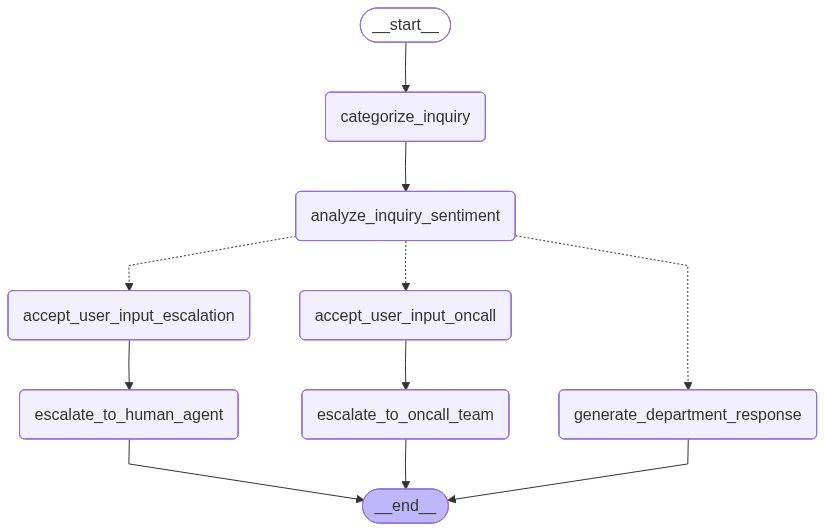

In [81]:
compiled_support_agent

In [82]:
# Helper function to run the agent

In [84]:
def call_support_agent(agent, prompt, user_session_id, verbose=False):
    events = agent.stream(
        {"customer_query": prompt}, # initial state of the agent
        {"configurable": {"thread_id": user_session_id}},
        stream_mode="values",
    )

    print('Running Agent. Please wait...')
    for event in events:
        if verbose:
                print(event)


    print('\nFinal Response:')
    display((event['final_response']))

In [85]:
# Testing for customer support router RAG agent

In [87]:
[item['text'] for item in knowledge_data_base]

["Question: How can I view my healthcare billing statement online? Answer: You can view your billing statement by logging into your patient portal and selecting 'Billing Statements'.",
 'Question: What payment methods are accepted for medical bills? Answer: We accept credit cards, bank transfers, and insurance payments for settling your medical bills.',
 'Question: Can I get a detailed invoice for my medical services? Answer: Yes, a detailed invoice is available in your patient portal under the billing section.',
 'Question: Is there a discount for upfront payment of my medical bill? Answer: Some facilities offer discounts for upfront payments; please contact our billing department for details.',
 'Question: How do I update my billing information on my healthcare account? Answer: You can update your billing details through your online patient portal in the account settings.',
 'Question: Are there any additional fees for medical billing services? Answer: All fees are clearly outlined i

In [88]:
uid = 'Abhijeet'
query = "I am unable to breathe properly, need help"
call_support_agent(agent=compiled_support_agent,
                   prompt=query,
                   user_session_id=uid,
                   verbose=True)

Running Agent. Please wait...
{'customer_query': 'I am unable to breathe properly, need help'}
{'customer_query': 'I am unable to breathe properly, need help', 'query_category': 'Appointments'}
{'customer_query': 'I am unable to breathe properly, need help', 'query_category': 'Appointments', 'query_sentiment': 'Distress'}


.....................................................{'customer_query': 'I am unable to breathe properly, need help', 'query_category': 'Appointments', 'query_sentiment': 'Distress', 'oncall_cust_info': {'name': 'abhijeet', 'number': '9168889973'}}
{'customer_query': 'I am unable to breathe properly, need help', 'query_category': 'Appointments', 'query_sentiment': 'Distress', 'oncall_cust_info': {'name': 'abhijeet', 'number': '9168889973'}, 'final_response': "Don't worry abhijeet!, someone from our on-call expert doctors will be reaching out to your shortly at 9168889973 for assistance immediately!"}

Final Response:


"Don't worry abhijeet!, someone from our on-call expert doctors will be reaching out to your shortly at 9168889973 for assistance immediately!"

In [89]:
uid = 'Abhijeet'
query = "Where i can get my invoice"
call_support_agent(agent=compiled_support_agent,
                   prompt=query,
                   user_session_id=uid,
                   verbose=True)

Running Agent. Please wait...
{'customer_query': 'Where i can get my invoice', 'query_category': 'Appointments', 'query_sentiment': 'Distress', 'oncall_cust_info': {'name': 'abhijeet', 'number': '9168889973'}, 'final_response': "Don't worry abhijeet!, someone from our on-call expert doctors will be reaching out to your shortly at 9168889973 for assistance immediately!"}
{'customer_query': 'Where i can get my invoice', 'query_category': 'Billing', 'query_sentiment': 'Distress', 'oncall_cust_info': {'name': 'abhijeet', 'number': '9168889973'}, 'final_response': "Don't worry abhijeet!, someone from our on-call expert doctors will be reaching out to your shortly at 9168889973 for assistance immediately!"}
{'customer_query': 'Where i can get my invoice', 'query_category': 'Billing', 'query_sentiment': 'Neutral', 'oncall_cust_info': {'name': 'abhijeet', 'number': '9168889973'}, 'final_response': "Don't worry abhijeet!, someone from our on-call expert doctors will be reaching out to your shor

"Thank you for reaching out with your query about obtaining your invoice. You can easily access your detailed invoice by logging into your patient portal. Once logged in, navigate to the 'Billing' section where you will find your invoice available for viewing and download. If you have any further questions or need assistance accessing your patient portal, please feel free to reach out."

In [90]:
uid = 'Abhijeet'
query = "This is very unprofessional behaviour from you"
call_support_agent(agent=compiled_support_agent,
                   prompt=query,
                   user_session_id=uid,
                   verbose=True)

Running Agent. Please wait...
{'customer_query': 'This is very unprofessional behaviour from you', 'query_category': 'Billing', 'query_sentiment': 'Neutral', 'oncall_cust_info': {'name': 'abhijeet', 'number': '9168889973'}, 'final_response': "Thank you for reaching out with your query about obtaining your invoice. You can easily access your detailed invoice by logging into your patient portal. Once logged in, navigate to the 'Billing' section where you will find your invoice available for viewing and download. If you have any further questions or need assistance accessing your patient portal, please feel free to reach out."}
{'customer_query': 'This is very unprofessional behaviour from you', 'query_category': 'Billing', 'query_sentiment': 'Neutral', 'oncall_cust_info': {'name': 'abhijeet', 'number': '9168889973'}, 'final_response': "Thank you for reaching out with your query about obtaining your invoice. You can easily access your detailed invoice by logging into your patient portal. 

...............................................................{'customer_query': 'This is very unprofessional behaviour from you', 'query_category': 'Billing', 'query_sentiment': 'Negative', 'escalation_cust_info': {'name': 'Abhi', 'number': '344234234423', 'email': 'abhi@gmail.com'}, 'oncall_cust_info': {'name': 'abhijeet', 'number': '9168889973'}, 'final_response': "Thank you for reaching out with your query about obtaining your invoice. You can easily access your detailed invoice by logging into your patient portal. Once logged in, navigate to the 'Billing' section where you will find your invoice available for viewing and download. If you have any further questions or need assistance accessing your patient portal, please feel free to reach out."}
{'customer_query': 'This is very unprofessional behaviour from you', 'query_category': 'Billing', 'query_sentiment': 'Negative', 'escalation_cust_info': {'name': 'Abhi', 'number': '344234234423', 'email': 'abhi@gmail.com'}, 'oncall_cust_i

'Apologies, Abhi,  we are really sorry! Someone from our team will be reaching out to via email shortly at abhi@gmail.com and if needed we will also be calling you at: 344234234423 to help you out!'